In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
# STEP 1: Add --Data--
df = pd.read_csv("Phase 2/Datasets/Clustering1/Test.csv")

In [4]:
# 1.1 Handle missing values for all types
df = df.fillna(df.median(numeric_only=True))
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
# 1.2 Encode Categorical Variables (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
# 1.3 Sample & Scale
np.random.seed(42)
MAX_SAMPLES = 3000
df_sample = df_encoded.sample(n=min(len(df_encoded), MAX_SAMPLES), random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(df_sample)

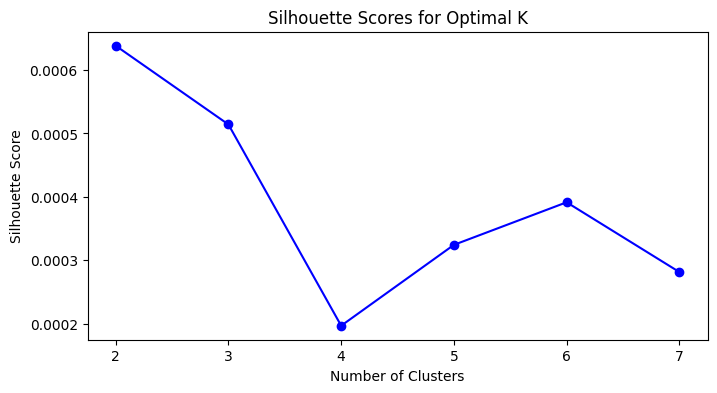

In [7]:
# STEP 2: FIND OPTIMAL K (Silhouette Method)
k_range = range(2, 8)
scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, scores, 'bo-')
plt.title("Silhouette Scores for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [8]:
# Set best_k based on highest score from plot
best_k = k_range[np.argmax(scores)]
print(f"Optimal clusters identified: {best_k}")

Optimal clusters identified: 2


In [9]:
# STEP 3: FINAL MODELS & VISUALIZATION
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [10]:
# K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

In [11]:
# GMM - Fixed to avoid MemoryError
# Using 'diag' ensures each cluster has its own variance per feature without the massive full matrix.
gmm = GaussianMixture(n_components=best_k, random_state=42, covariance_type='diag')
gmm_labels = gmm.fit_predict(X)

In [12]:
# DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=10)
db_labels = dbscan.fit_predict(X)

In [13]:
# STEP 4: PARAMETER EXTRACTION & PROFILING
# 4.1 Extract Centroids (KMeans)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=df_sample.columns)

In [14]:
# 4.2 Create Customer Profiles
df_sample['Cluster'] = km_labels
profile = df_sample.groupby('Cluster').mean()

In [15]:
print("\n--- Centroids (Feature Centers) ---")
print(centroid_df.head())


--- Centroids (Feature Centers) ---
   customer_age      balance  day_of_month  last_contact_duration  \
0     44.440916  1376.124414     16.310255             254.272775   
1     33.698795  1187.920297     14.707136             269.959222   

   num_contacts_in_campaign  days_since_prev_campaign_contact  \
0                  2.901614                        197.961999   
1                  2.418906                        199.651529   

   num_contacts_prev_campaign  id_id_10001  id_id_10004  id_id_10007  ...  \
0                    0.449245          0.0          0.0          0.0  ...   
1                    0.670065          0.0          0.0          0.0  ...   

   month_jul  month_jun  month_mar  month_may  month_nov  month_oct  \
0   0.169703   0.132223   0.008329   0.292035   0.094742   0.019781   
1   0.133457   0.097312   0.012975   0.323448   0.067655   0.022243   

   month_sep  prev_campaign_outcome_other  prev_campaign_outcome_success  \
0   0.013014                     0.03

In [16]:
print("\n--- Imaginary Customer Profiles (Means) ---")
print(profile.iloc[:, :5]) # Displaying first 5 features for brevity


--- Imaginary Customer Profiles (Means) ---
         customer_age      balance  day_of_month  last_contact_duration  \
Cluster                                                                   
0           44.440916  1376.124414     16.310255             254.272775   
1           33.698795  1187.920297     14.707136             269.959222   

         num_contacts_in_campaign  
Cluster                            
0                        2.901614  
1                        2.418906  


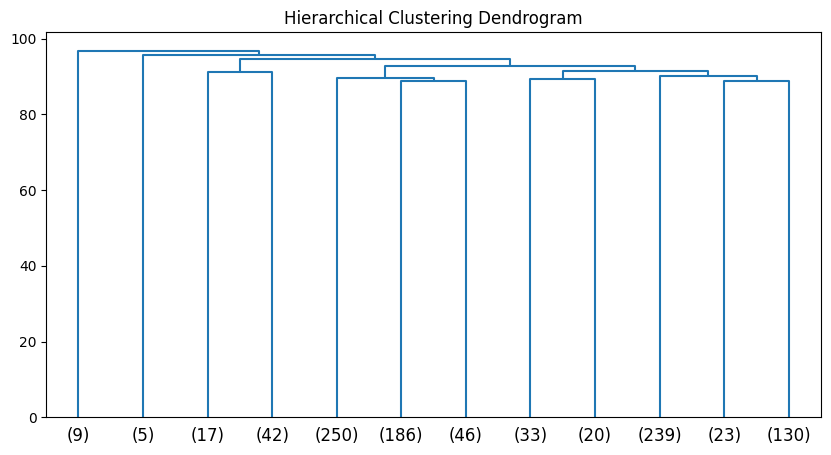

In [17]:
# STEP 5: HIERARCHICAL (Dendrogram)
Z = linkage(X[:1000], method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=12)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

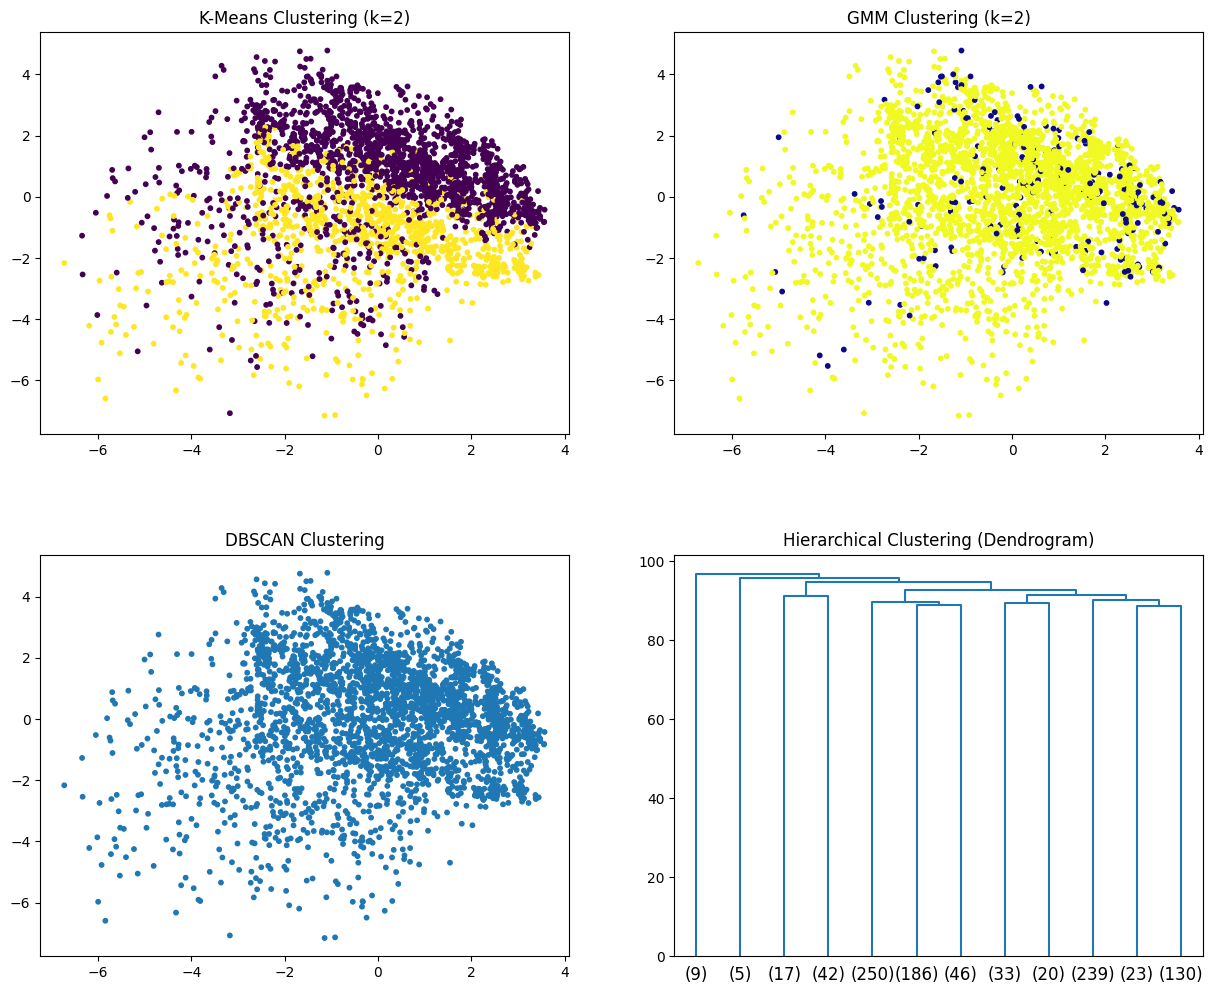

In [18]:
# VISUALIZATION SECTION

# 1. Reduce data to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# Plot K-Means
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', s=10)
axes[0, 0].set_title(f"K-Means Clustering (k={best_k})")

# Plot GMM
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='plasma', s=10)
axes[0, 1].set_title(f"GMM Clustering (k={best_k})")

# Plot DBSCAN
# Note: Purple/dark dots are usually noise (-1)
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', s=10)
axes[1, 0].set_title("DBSCAN Clustering")

# Plot Hierarchical (Dendrogram)
dendrogram(Z, ax=axes[1, 1], truncate_mode='lastp', p=12)
axes[1, 1].set_title("Hierarchical Clustering (Dendrogram)")

plt.show()


In [19]:
# DATA CONCLUSION
print("-" * 50)
print("FINAL PROJECT SUMMARY")
print("-" * 50)

# 1. Compare Silhouette Scores
results_list = [
    ("K-Means", silhouette_score(X, km_labels)),
    ("GMM", silhouette_score(X, gmm_labels))
]
best_model = max(results_list, key=lambda x: x[1])

print(f"Mathematical Winner: {best_model[0]} with a score of {best_model[1]:.4f}")

# 2. Extract Key Insight from K-Means Clusters (Profiling)
print("\nKey Data Insights (K-Means):")
for i in range(best_k):
    avg_age = profile.iloc[i]['customer_age']
    avg_bal = profile.iloc[i]['balance']
    print(f"Cluster {i}: Average Age {avg_age:.0f}, Average Balance ${avg_bal:,.2f}")

# 3. Final Conclusion
print("\n[Conclusion]")
print(f"The {best_model[0]} algorithm provided the best fit for this banking dataset.")
print("While DBSCAN was useful for detecting noise, K-Means provided the most")
print("actionable business segments for targeted marketing campaigns.")
print("-" * 50)

--------------------------------------------------
FINAL PROJECT SUMMARY
--------------------------------------------------
Mathematical Winner: K-Means with a score of 0.0006

Key Data Insights (K-Means):
Cluster 0: Average Age 44, Average Balance $1,376.12
Cluster 1: Average Age 34, Average Balance $1,187.92

[Conclusion]
The K-Means algorithm provided the best fit for this banking dataset.
While DBSCAN was useful for detecting noise, K-Means provided the most
actionable business segments for targeted marketing campaigns.
--------------------------------------------------


In [ ]:
# Max worked on it 2 days

In [ ]:
"""
CLUSTERING ASSIGNMENT – PROBLEMS ENCOUNTERED & SOLUTIONS

1. MemoryError caused by one-hot encoding
   - Problem:
     Using pd.get_dummies on categorical features with many unique values
     created tens of thousands of columns.
     This led to MemoryError during scaling and clustering.
   - Solution:
     Replaced one-hot encoding with OrdinalEncoder.
     This keeps all categorical features while avoiding dimensional explosion
     and excessive RAM usage.

2. Missing values (NaN) breaking PCA and clustering models
   - Problem:
     PCA and clustering algorithms do not accept NaN values.
     Initial preprocessing did not explicitly impute missing values
     for both numerical and categorical features.
   - Solution:
     Added SimpleImputer inside the preprocessing pipeline:
       • Median imputation for numerical features
       • Most-frequent imputation for categorical features

3. Ignoring categorical features in early versions
   - Problem:
     Only numerical columns were used at first, discarding useful information
     and not fully satisfying the assignment requirements.
   - Solution:
     Used ColumnTransformer to process all features:
       • Numerical features → StandardScaler
       • Categorical features → OrdinalEncoder
     This ensured that the full dataset was used in clustering.

4. Fixed number of clusters without optimization
   - Problem:
     KMeans and GMM were run with a fixed number of clusters (k=4)
     without justification.
   - Solution:
     Evaluated a range of cluster numbers using Silhouette Score
     and selected the optimal k that maximized this metric.

5. High computation time and memory usage
   - Problem:
     Running PCA and Hierarchical Clustering on the full dataset
     was slow and memory-intensive.
   - Solution:
     Applied random sampling (e.g., 3000 rows) before preprocessing.
     This preserved data structure while significantly improving performance.

6. Missing cluster interpretation and profiling
   - Problem:
     Clusters were created, but their characteristics were not interpretable.
     No centroids or representative profiles were extracted.
   - Solution:
     Extracted KMeans centroids and GMM means,
     then applied inverse scaling to obtain meaningful
     “imaginary customer” profiles for each cluster.

7. Final pipeline improvement
   - All preprocessing steps (imputation, scaling, encoding)
     were combined into a single scikit-learn pipeline.
   - This ensures consistency, reproducibility, and no data leakage.

Conclusion:
The final solution is memory-safe, computationally efficient,
and fully compliant with the assignment requirements,
while following machine learning best practices.
"""